<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-7-Three_Nonlinear_Hamiltonian%20Systems/Untitled191.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Double Pendulum**

**Hamiltonian approach**

1. The short-run regime: $T=2$

Epoch 1/3000


<>:482: SyntaxWarning: invalid escape sequence '\p'
<>:489: SyntaxWarning: invalid escape sequence '\p'
<>:497: SyntaxWarning: invalid escape sequence '\p'
<>:505: SyntaxWarning: invalid escape sequence '\p'
<>:482: SyntaxWarning: invalid escape sequence '\p'
<>:489: SyntaxWarning: invalid escape sequence '\p'
<>:497: SyntaxWarning: invalid escape sequence '\p'
<>:505: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_10035/3699397527.py:482: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_1$'
/tmp/ipykernel_10035/3699397527.py:489: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_2$'
/tmp/ipykernel_10035/3699397527.py:497: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_1$'
/tmp/ipykernel_10035/3699397527.py:505: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_2$'


Streaming output truncated to the last 5000 lines.
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0060
Epoch 502/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0058
Epoch 503/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0058
Epoch 504/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0057
Epoch 505/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0057
Epoch 506/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0056
Epoch 507/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0056
Epoch 508/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0055
Epoch 509/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0058
Epoch 510/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1438
Epoch 511/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0591
Epoch 512/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0147
Epoch 513/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0073
Epoch 514/3000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

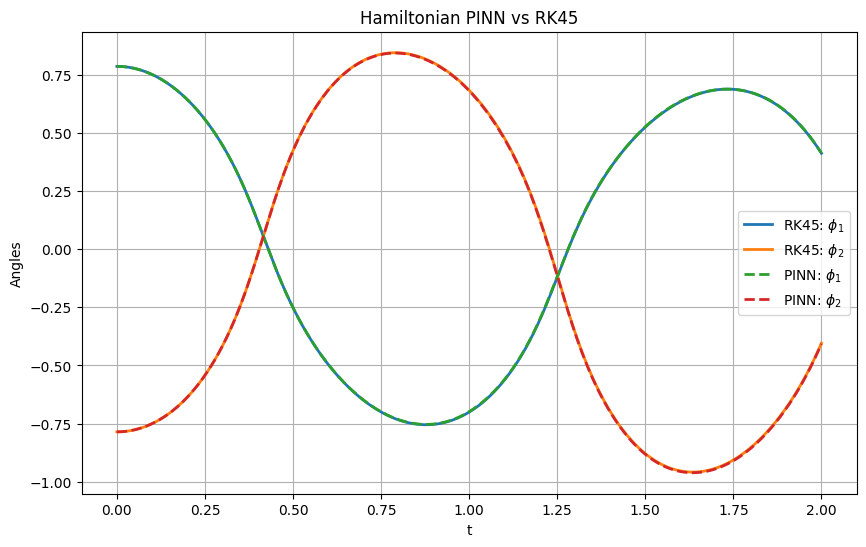

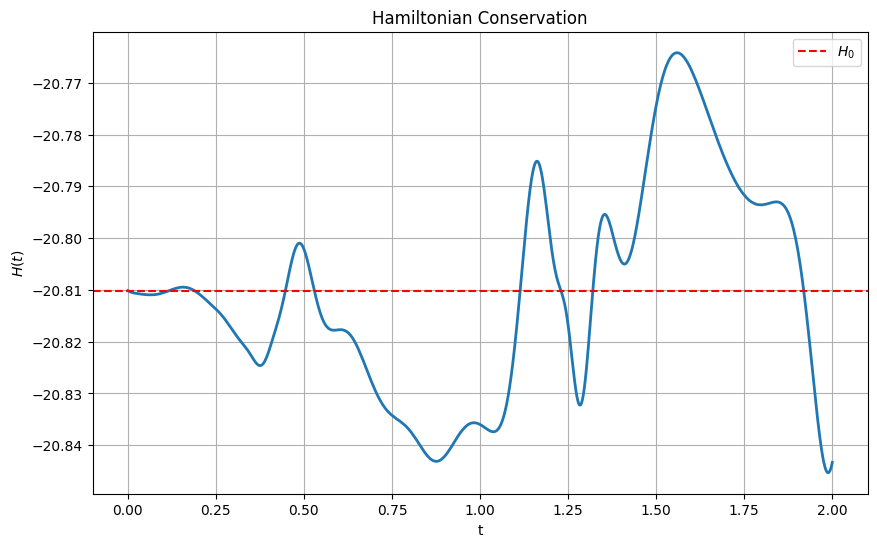

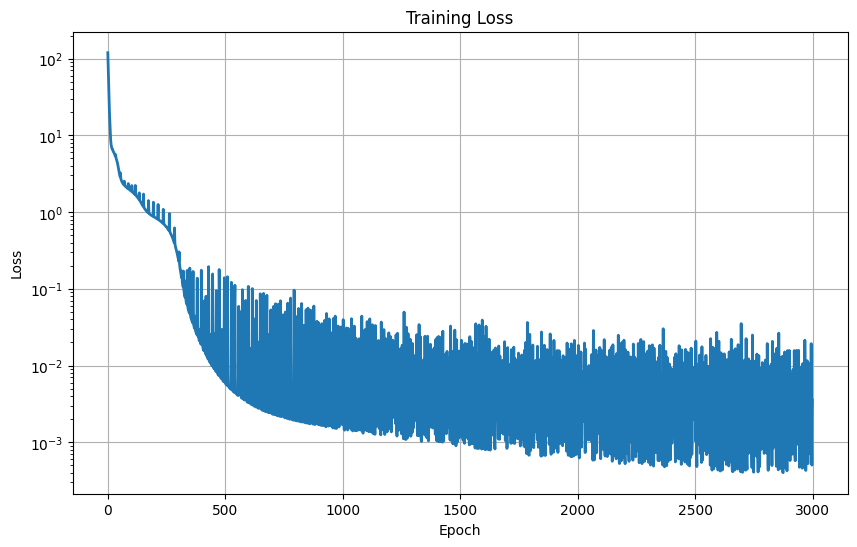

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

# ============================================================
# Physical parameters
# ============================================================

m1 = 1.0
m2 = 1.0

l1 = 1.0
l2 = 1.0

g = 9.81

# ============================================================
# Initial conditions
# ============================================================

phi0 = np.array([np.pi/4, -np.pi/4], dtype=np.float32)

p0 = np.array([0.0, 0.0], dtype=np.float32)

# ============================================================
# Time horizon
# ============================================================

T = 2.0

# ============================================================
# Training points
# ============================================================

t_train = np.linspace(
    0,
    T,
    1000
).reshape(-1,1)

# ============================================================
# Mass matrix inverse
# ============================================================

def M_inv(phi1, phi2):

    delta = phi1 - phi2

    denom = (
        m1
        +
        m2 * tf.sin(delta)**2
    )

    a11 = 1.0 / (l1**2 * denom)

    a12 = (
        -tf.cos(delta)
        /
        (l1*l2*denom)
    )

    a22 = (
        (m1+m2)
        /
        (m2*l2**2*denom)
    )

    return a11, a12, a22

# ============================================================
# Potential energy
# ============================================================

def potential(phi1, phi2):

    return (

        -(m1+m2)*g*l1*tf.cos(phi1)

        -

        m2*g*l2*tf.cos(phi2)

    )

# ============================================================
# Hamiltonian
# ============================================================

def Hamiltonian(phi1, phi2, p1, p2):

    a11, a12, a22 = M_inv(phi1, phi2)

    kinetic = (

        0.5 * (
            a11 * p1**2
            +
            2*a12*p1*p2
            +
            a22*p2**2
        )

    )

    return kinetic + potential(phi1, phi2)

# ============================================================
# Initial energy
# ============================================================

H0 = Hamiltonian(

    tf.constant(phi0[0]),
    tf.constant(phi0[1]),

    tf.constant(p0[0]),
    tf.constant(p0[1])

).numpy()

# ============================================================
# Runge-Kutta reference solution
# ============================================================

def rhs(t, y):

    phi1, phi2, p1, p2 = y

    delta = phi1 - phi2

    denom = (
        m1
        +
        m2*np.sin(delta)**2
    )

    phi1_dot = (

        p1/l1**2
        -
        np.cos(delta)*p2/(l1*l2)

    ) / denom

    phi2_dot = (

        -(np.cos(delta)/(l1*l2))*p1
        +
        ((m1+m2)/(m2*l2**2))*p2

    ) / denom

    coupling = (
        m2*l1*l2
        * phi1_dot
        * phi2_dot
        * np.sin(delta)
    )

    p1_dot = (
        -coupling
        -
        (m1+m2)*g*l1*np.sin(phi1)
    )

    p2_dot = (
        coupling
        -
        m2*g*l2*np.sin(phi2)
    )

    return [
        phi1_dot,
        phi2_dot,
        p1_dot,
        p2_dot
    ]

# ============================================================
# RK solution
# ============================================================

t_eval = np.linspace(0, T, 3000)

sol = solve_ivp(

    rhs,

    [0, T],

    [
        phi0[0],
        phi0[1],
        p0[0],
        p0[1]
    ],

    t_eval=t_eval,

    rtol=1e-10,
    atol=1e-10

)

phi1_rk = sol.y[0]
phi2_rk = sol.y[1]

# ============================================================
# Neural network
# ============================================================

model = Sequential([

    Input(shape=(1,)),

    Dense(80, activation='tanh'),

    Dense(80, activation='tanh'),

    Dense(80, activation='tanh'),

    Dense(4)

])

# ============================================================
# Hard embedding
# ============================================================

def pinn_solution(t):

    NN = model(t)

    N1 = NN[:,0:1]
    N2 = NN[:,1:2]

    N3 = NN[:,2:3]
    N4 = NN[:,3:4]

    phi1 = phi0[0] + t*N1
    phi2 = phi0[1] + t*N2

    p1 = p0[0] + t*N3
    p2 = p0[1] + t*N4

    return phi1, phi2, p1, p2

# ============================================================
# Loss function
# ============================================================

def custom_loss(y_true, y_pred):

    t_input = tf.convert_to_tensor(
        t_train,
        dtype=tf.float32
    )

    with tf.GradientTape(persistent=True) as tape:

        tape.watch(t_input)

        phi1, phi2, p1, p2 = pinn_solution(t_input)

    phi1_dot = tape.gradient(phi1, t_input)
    phi2_dot = tape.gradient(phi2, t_input)

    p1_dot = tape.gradient(p1, t_input)
    p2_dot = tape.gradient(p2, t_input)

    delta = phi1 - phi2

    # ========================================================
    # Hamilton equations
    # ========================================================

    denom = (
        m1
        +
        m2*tf.sin(delta)**2
    )

    phi1_rhs = (

        p1/l1**2
        -
        tf.cos(delta)*p2/(l1*l2)

    ) / denom

    phi2_rhs = (

        -(tf.cos(delta)/(l1*l2))*p1
        +
        ((m1+m2)/(m2*l2**2))*p2

    ) / denom

    coupling = (
        m2*l1*l2
        * phi1_dot
        * phi2_dot
        * tf.sin(delta)
    )

    p1_rhs = (
        -coupling
        -
        (m1+m2)*g*l1*tf.sin(phi1)
    )

    p2_rhs = (
        coupling
        -
        m2*g*l2*tf.sin(phi2)
    )

    # ========================================================
    # Residuals
    # ========================================================

    R1 = phi1_dot - phi1_rhs
    R2 = phi2_dot - phi2_rhs

    R3 = p1_dot - p1_rhs
    R4 = p2_dot - p2_rhs

    physics_loss = tf.reduce_mean(

        R1**2 + R2**2 + R3**2 + R4**2

    )

    # ========================================================
    # Hamiltonian conservation
    # ========================================================

    H = Hamiltonian(
        phi1,
        phi2,
        p1,
        p2
    )

    energy_loss = tf.reduce_mean(
        (H - H0)**2
    )

    return (
        physics_loss
        +
        0.1*energy_loss
    )

# ============================================================
# Compile
# ============================================================

model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss=custom_loss

)

# ============================================================
# Dummy targets
# ============================================================

dummy_target = np.zeros(
    (t_train.shape[0], 4)
)

# ============================================================
# Train
# ============================================================

history = model.fit(

    t_train,

    dummy_target,

    epochs=3000,

    batch_size=64,

    verbose=1

)

# ============================================================
# Predictions
# ============================================================

t_plot = np.linspace(
    0,
    T,
    3000
).reshape(-1,1)

t_tensor = tf.convert_to_tensor(
    t_plot,
    dtype=tf.float32
)

phi1_nn, phi2_nn, p1_nn, p2_nn = pinn_solution(t_tensor)

phi1_nn = phi1_nn.numpy().flatten()
phi2_nn = phi2_nn.numpy().flatten()

p1_nn = p1_nn.numpy().flatten()
p2_nn = p2_nn.numpy().flatten()

# ============================================================
# Energy
# ============================================================

delta_nn = phi1_nn - phi2_nn

denom_nn = (
    m1
    +
    m2*np.sin(delta_nn)**2
)

a11 = 1.0/(l1**2*denom_nn)

a12 = (
    -np.cos(delta_nn)
    /
    (l1*l2*denom_nn)
)

a22 = (
    (m1+m2)
    /
    (m2*l2**2*denom_nn)
)

H_nn = (

    0.5 * (
        a11*p1_nn**2
        +
        2*a12*p1_nn*p2_nn
        +
        a22*p2_nn**2
    )

    -

    (m1+m2)*g*l1*np.cos(phi1_nn)

    -

    m2*g*l2*np.cos(phi2_nn)

)

# ============================================================
# Plot 1:
# Angles
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_eval,
    phi1_rk,
    linewidth=2,
    label='RK45: $\phi_1$'
)

plt.plot(
    t_eval,
    phi2_rk,
    linewidth=2,
    label='RK45: $\phi_2$'
)

plt.plot(
    t_plot,
    phi1_nn,
    '--',
    linewidth=2,
    label='PINN: $\phi_1$'
)

plt.plot(
    t_plot,
    phi2_nn,
    '--',
    linewidth=2,
    label='PINN: $\phi_2$'
)

plt.xlabel('t')
plt.ylabel('Angles')

plt.title(
    'Hamiltonian PINN vs RK45'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 2:
# Hamiltonian
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_plot,
    H_nn,
    linewidth=2
)

plt.axhline(
    H0,
    color='red',
    linestyle='--',
    label='$H_0$'
)

plt.xlabel('t')
plt.ylabel('$H(t)$')

plt.title(
    'Hamiltonian Conservation'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 3:
# Loss
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    history.history['loss'],
    linewidth=2
)

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Training Loss'
)

plt.grid()

plt.show()

2. The long-run regime: $T=10$

<>:482: SyntaxWarning: invalid escape sequence '\p'
<>:489: SyntaxWarning: invalid escape sequence '\p'
<>:497: SyntaxWarning: invalid escape sequence '\p'
<>:505: SyntaxWarning: invalid escape sequence '\p'
<>:482: SyntaxWarning: invalid escape sequence '\p'
<>:489: SyntaxWarning: invalid escape sequence '\p'
<>:497: SyntaxWarning: invalid escape sequence '\p'
<>:505: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_10035/4013202975.py:482: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_1$'
/tmp/ipykernel_10035/4013202975.py:489: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_2$'
/tmp/ipykernel_10035/4013202975.py:497: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_1$'
/tmp/ipykernel_10035/4013202975.py:505: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_2$'


Epoch 1/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 245.9072
Epoch 2/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 232.9957
Epoch 3/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 209.4416
Epoch 4/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 187.0241
Epoch 5/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 182.8404
Epoch 6/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 191.6753
Epoch 7/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 169.0639
Epoch 8/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 155.9053
Epoch 9/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 152.6388
Epoch 10/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 149.1983
Epoch 11/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 144.7284
Epoch 12/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 136.8078
Epoch 13/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 122.9047
Epoch 14/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 105.6710
Epoch 15/1000
7

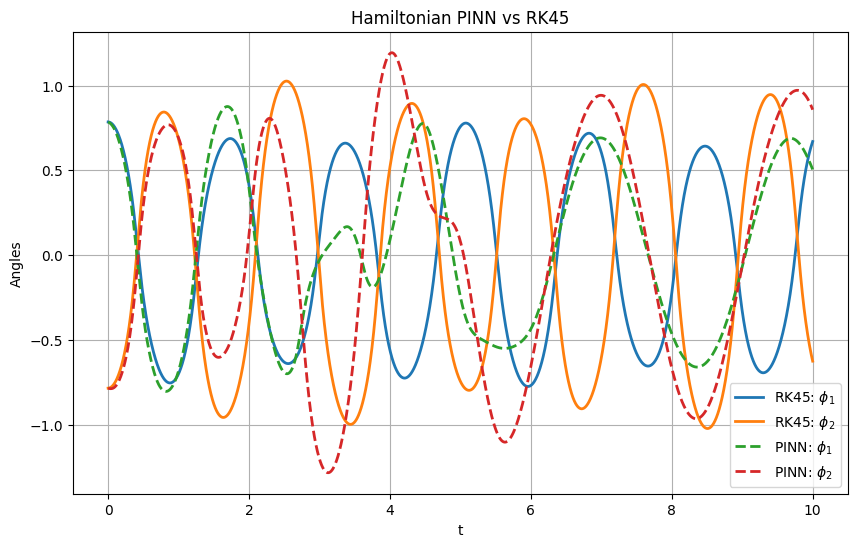

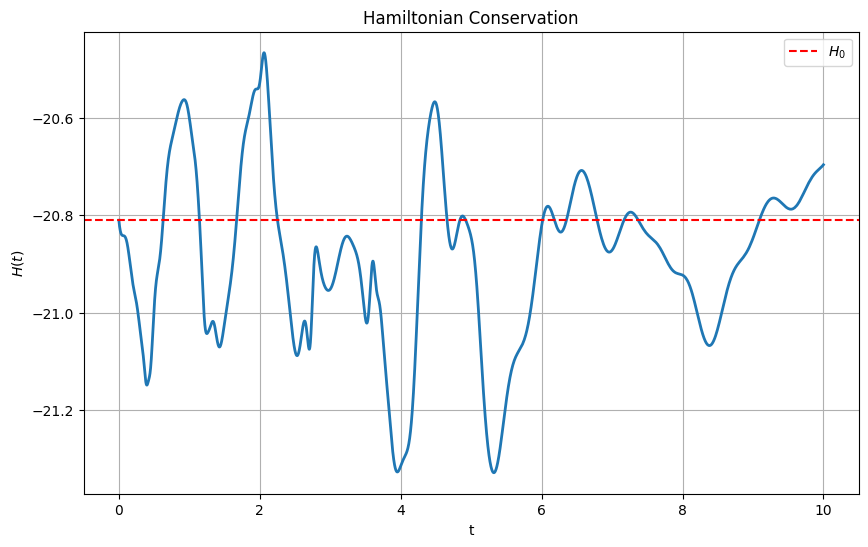

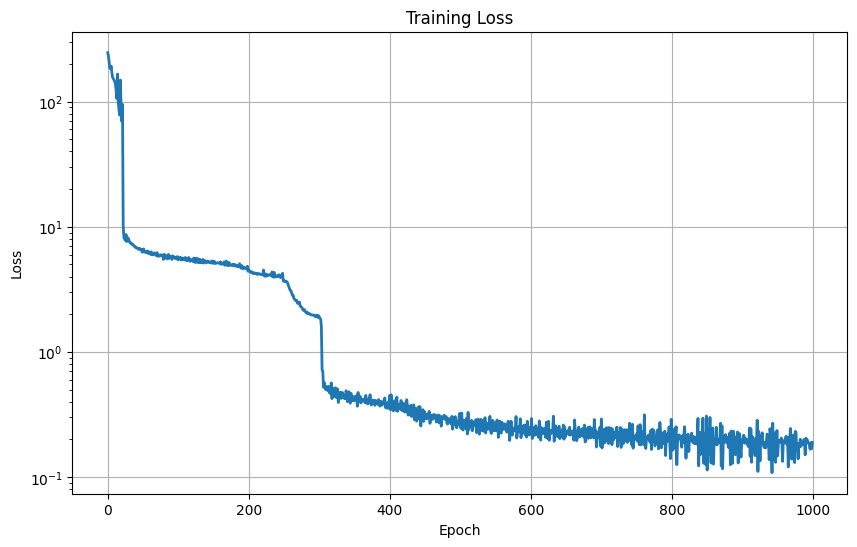

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

# ============================================================
# Physical parameters
# ============================================================

m1 = 1.0
m2 = 1.0

l1 = 1.0
l2 = 1.0

g = 9.81

# ============================================================
# Initial conditions
# ============================================================

phi0 = np.array([np.pi/4, -np.pi/4], dtype=np.float32)

p0 = np.array([0.0, 0.0], dtype=np.float32)

# ============================================================
# Time horizon
# ============================================================

T = 10.0

# ============================================================
# Training points
# ============================================================

t_train = np.linspace(
    0,
    T,
    5000
).reshape(-1,1)

# ============================================================
# Mass matrix inverse
# ============================================================

def M_inv(phi1, phi2):

    delta = phi1 - phi2

    denom = (
        m1
        +
        m2 * tf.sin(delta)**2
    )

    a11 = 1.0 / (l1**2 * denom)

    a12 = (
        -tf.cos(delta)
        /
        (l1*l2*denom)
    )

    a22 = (
        (m1+m2)
        /
        (m2*l2**2*denom)
    )

    return a11, a12, a22

# ============================================================
# Potential energy
# ============================================================

def potential(phi1, phi2):

    return (

        -(m1+m2)*g*l1*tf.cos(phi1)

        -

        m2*g*l2*tf.cos(phi2)

    )

# ============================================================
# Hamiltonian
# ============================================================

def Hamiltonian(phi1, phi2, p1, p2):

    a11, a12, a22 = M_inv(phi1, phi2)

    kinetic = (

        0.5 * (
            a11 * p1**2
            +
            2*a12*p1*p2
            +
            a22*p2**2
        )

    )

    return kinetic + potential(phi1, phi2)

# ============================================================
# Initial energy
# ============================================================

H0 = Hamiltonian(

    tf.constant(phi0[0]),
    tf.constant(phi0[1]),

    tf.constant(p0[0]),
    tf.constant(p0[1])

).numpy()

# ============================================================
# Runge-Kutta reference solution
# ============================================================

def rhs(t, y):

    phi1, phi2, p1, p2 = y

    delta = phi1 - phi2

    denom = (
        m1
        +
        m2*np.sin(delta)**2
    )

    phi1_dot = (

        p1/l1**2
        -
        np.cos(delta)*p2/(l1*l2)

    ) / denom

    phi2_dot = (

        -(np.cos(delta)/(l1*l2))*p1
        +
        ((m1+m2)/(m2*l2**2))*p2

    ) / denom

    coupling = (
        m2*l1*l2
        * phi1_dot
        * phi2_dot
        * np.sin(delta)
    )

    p1_dot = (
        -coupling
        -
        (m1+m2)*g*l1*np.sin(phi1)
    )

    p2_dot = (
        coupling
        -
        m2*g*l2*np.sin(phi2)
    )

    return [
        phi1_dot,
        phi2_dot,
        p1_dot,
        p2_dot
    ]

# ============================================================
# RK solution
# ============================================================

t_eval = np.linspace(0, T, 5000)

sol = solve_ivp(

    rhs,

    [0, T],

    [
        phi0[0],
        phi0[1],
        p0[0],
        p0[1]
    ],

    t_eval=t_eval,

    rtol=1e-10,
    atol=1e-10

)

phi1_rk = sol.y[0]
phi2_rk = sol.y[1]

# ============================================================
# Neural network
# ============================================================

model = Sequential([

    Input(shape=(1,)),

    Dense(80, activation='tanh'),

    Dense(80, activation='tanh'),

    Dense(80, activation='tanh'),

    Dense(4)

])

# ============================================================
# Hard embedding
# ============================================================

def pinn_solution(t):

    NN = model(t)

    N1 = NN[:,0:1]
    N2 = NN[:,1:2]

    N3 = NN[:,2:3]
    N4 = NN[:,3:4]

    phi1 = phi0[0] + t*N1
    phi2 = phi0[1] + t*N2

    p1 = p0[0] + t*N3
    p2 = p0[1] + t*N4

    return phi1, phi2, p1, p2

# ============================================================
# Loss function
# ============================================================

def custom_loss(y_true, y_pred):

    t_input = tf.convert_to_tensor(
        t_train,
        dtype=tf.float32
    )

    with tf.GradientTape(persistent=True) as tape:

        tape.watch(t_input)

        phi1, phi2, p1, p2 = pinn_solution(t_input)

    phi1_dot = tape.gradient(phi1, t_input)
    phi2_dot = tape.gradient(phi2, t_input)

    p1_dot = tape.gradient(p1, t_input)
    p2_dot = tape.gradient(p2, t_input)

    delta = phi1 - phi2

    # ========================================================
    # Hamilton equations
    # ========================================================

    denom = (
        m1
        +
        m2*tf.sin(delta)**2
    )

    phi1_rhs = (

        p1/l1**2
        -
        tf.cos(delta)*p2/(l1*l2)

    ) / denom

    phi2_rhs = (

        -(tf.cos(delta)/(l1*l2))*p1
        +
        ((m1+m2)/(m2*l2**2))*p2

    ) / denom

    coupling = (
        m2*l1*l2
        * phi1_dot
        * phi2_dot
        * tf.sin(delta)
    )

    p1_rhs = (
        -coupling
        -
        (m1+m2)*g*l1*tf.sin(phi1)
    )

    p2_rhs = (
        coupling
        -
        m2*g*l2*tf.sin(phi2)
    )

    # ========================================================
    # Residuals
    # ========================================================

    R1 = phi1_dot - phi1_rhs
    R2 = phi2_dot - phi2_rhs

    R3 = p1_dot - p1_rhs
    R4 = p2_dot - p2_rhs

    physics_loss = tf.reduce_mean(

        R1**2 + R2**2 + R3**2 + R4**2

    )

    # ========================================================
    # Hamiltonian conservation
    # ========================================================

    H = Hamiltonian(
        phi1,
        phi2,
        p1,
        p2
    )

    energy_loss = tf.reduce_mean(
        (H - H0)**2
    )

    return (
        physics_loss
        +
        0.1*energy_loss
    )

# ============================================================
# Compile
# ============================================================

model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss=custom_loss

)

# ============================================================
# Dummy targets
# ============================================================

dummy_target = np.zeros(
    (t_train.shape[0], 4)
)

# ============================================================
# Train
# ============================================================

history = model.fit(

    t_train,

    dummy_target,

    epochs=1000,

    batch_size=64,

    verbose=1

)

# ============================================================
# Predictions
# ============================================================

t_plot = np.linspace(
    0,
    T,
    5000
).reshape(-1,1)

t_tensor = tf.convert_to_tensor(
    t_plot,
    dtype=tf.float32
)

phi1_nn, phi2_nn, p1_nn, p2_nn = pinn_solution(t_tensor)

phi1_nn = phi1_nn.numpy().flatten()
phi2_nn = phi2_nn.numpy().flatten()

p1_nn = p1_nn.numpy().flatten()
p2_nn = p2_nn.numpy().flatten()

# ============================================================
# Energy
# ============================================================

delta_nn = phi1_nn - phi2_nn

denom_nn = (
    m1
    +
    m2*np.sin(delta_nn)**2
)

a11 = 1.0/(l1**2*denom_nn)

a12 = (
    -np.cos(delta_nn)
    /
    (l1*l2*denom_nn)
)

a22 = (
    (m1+m2)
    /
    (m2*l2**2*denom_nn)
)

H_nn = (

    0.5 * (
        a11*p1_nn**2
        +
        2*a12*p1_nn*p2_nn
        +
        a22*p2_nn**2
    )

    -

    (m1+m2)*g*l1*np.cos(phi1_nn)

    -

    m2*g*l2*np.cos(phi2_nn)

)

# ============================================================
# Plot 1:
# Angles
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_eval,
    phi1_rk,
    linewidth=2,
    label='RK45: $\phi_1$'
)

plt.plot(
    t_eval,
    phi2_rk,
    linewidth=2,
    label='RK45: $\phi_2$'
)

plt.plot(
    t_plot,
    phi1_nn,
    '--',
    linewidth=2,
    label='PINN: $\phi_1$'
)

plt.plot(
    t_plot,
    phi2_nn,
    '--',
    linewidth=2,
    label='PINN: $\phi_2$'
)

plt.xlabel('t')
plt.ylabel('Angles')

plt.title(
    'Hamiltonian PINN vs RK45'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 2:
# Hamiltonian
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_plot,
    H_nn,
    linewidth=2
)

plt.axhline(
    H0,
    color='red',
    linestyle='--',
    label='$H_0$'
)

plt.xlabel('t')
plt.ylabel('$H(t)$')

plt.title(
    'Hamiltonian Conservation'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 3:
# Loss
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    history.history['loss'],
    linewidth=2
)

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Training Loss'
)

plt.grid()

plt.show()

The long-run regime improved.

<>:552: SyntaxWarning: invalid escape sequence '\p'
<>:559: SyntaxWarning: invalid escape sequence '\p'
<>:567: SyntaxWarning: invalid escape sequence '\p'
<>:575: SyntaxWarning: invalid escape sequence '\p'
<>:552: SyntaxWarning: invalid escape sequence '\p'
<>:559: SyntaxWarning: invalid escape sequence '\p'
<>:567: SyntaxWarning: invalid escape sequence '\p'
<>:575: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1004/1996622910.py:552: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_1$'
/tmp/ipykernel_1004/1996622910.py:559: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_2$'
/tmp/ipykernel_1004/1996622910.py:567: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_1$'
/tmp/ipykernel_1004/1996622910.py:575: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_2$'


Epoch 0, Loss = 1.578764e+03
Epoch 100, Loss = 9.282512e+01
Epoch 200, Loss = 6.237186e+01
Epoch 300, Loss = 4.401212e+01
Epoch 400, Loss = 3.263393e+01
Epoch 500, Loss = 2.376683e+01
Epoch 600, Loss = 2.018587e+01
Epoch 700, Loss = 1.861097e+01
Epoch 800, Loss = 1.759081e+01
Epoch 900, Loss = 1.681958e+01
Epoch 1000, Loss = 1.621031e+01
Epoch 1100, Loss = 1.883064e+01
Epoch 1200, Loss = 1.523878e+01
Epoch 1300, Loss = 1.483380e+01
Epoch 1400, Loss = 1.449288e+01
Epoch 1500, Loss = 1.410687e+01
Epoch 1600, Loss = 1.383525e+01
Epoch 1700, Loss = 1.355523e+01
Epoch 1800, Loss = 1.317819e+01
Epoch 1900, Loss = 1.283834e+01
Epoch 2000, Loss = 1.255045e+01
Epoch 2100, Loss = 1.233498e+01
Epoch 2200, Loss = 1.289323e+01
Epoch 2300, Loss = 1.186811e+01
Epoch 2400, Loss = 1.187416e+01
Epoch 2500, Loss = 1.131622e+01
Epoch 2600, Loss = 1.131359e+01
Epoch 2700, Loss = 1.095960e+01
Epoch 2800, Loss = 1.093825e+01
Epoch 2900, Loss = 1.077237e+01
Epoch 3000, Loss = 1.033214e+01
Epoch 3100, Loss = 1

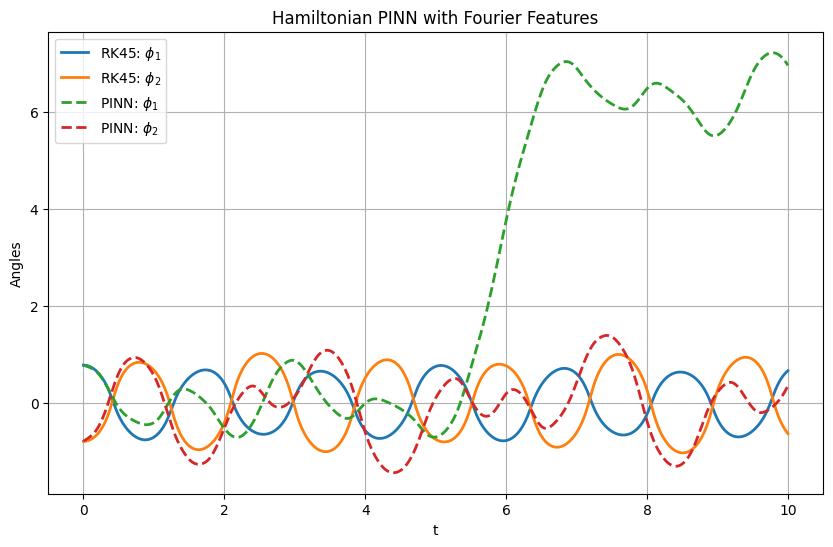

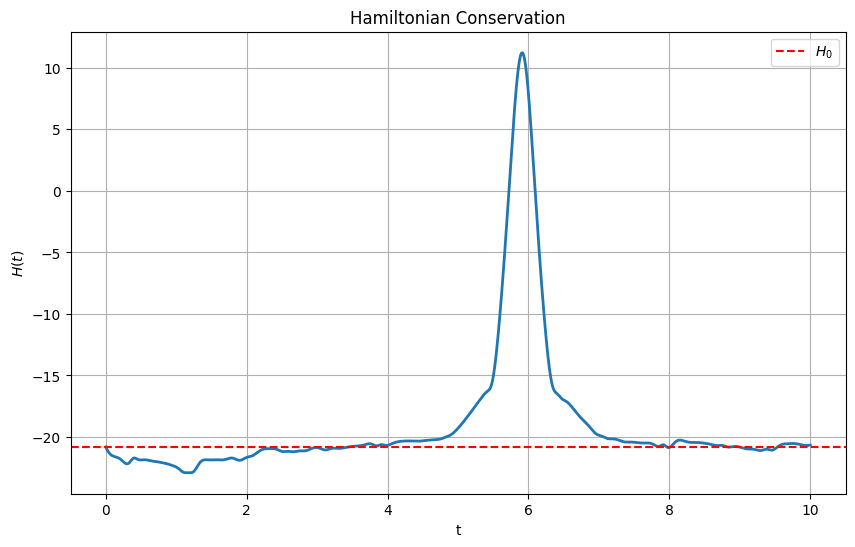

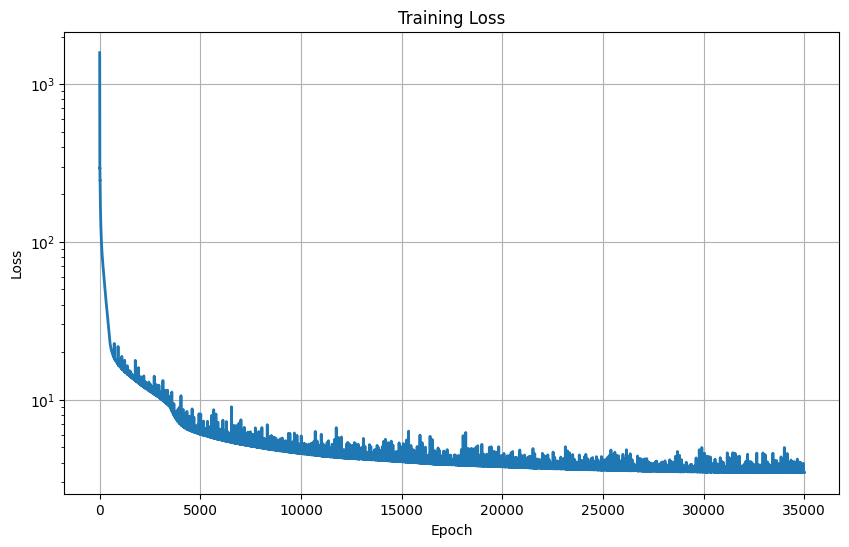

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Layer
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

# ============================================================
# Physical parameters
# ============================================================

m1 = 1.0
m2 = 1.0

l1 = 1.0
l2 = 1.0

g = 9.81

# ============================================================
# Initial conditions
# ============================================================

phi0 = np.array([np.pi/4, -np.pi/4], dtype=np.float32)

p0 = np.array([0.0, 0.0], dtype=np.float32)

# ============================================================
# Time horizon
# ============================================================

T = 10.0

# ============================================================
# Training points
# ============================================================

N_train = 4000

t_train = np.linspace(
    0,
    T,
    N_train
).reshape(-1,1)

# ============================================================
# Fourier feature layer
# ============================================================

class FourierLayer(Layer):

    def __init__(self, K=5):

        super().__init__()

        self.K = K

    def call(self, t):

        features = [t]

        for k in range(1, self.K + 1):

            features.append(
                tf.sin(k*t)
            )

            features.append(
                tf.cos(k*t)
            )

        return tf.concat(features, axis=1)

# ============================================================
# Hamiltonian PINN model
# Fourier layer + tanh layers
# ============================================================

class HamiltonianPINN(Model):

    def __init__(self):

        super().__init__()

        # Fourier features
        self.fourier = FourierLayer(K=5)

        # Standard tanh FNN
        self.d1 = Dense(
            80,
            activation='tanh'
        )

        self.d2 = Dense(
            80,
            activation='tanh'
        )

        self.d3 = Dense(
            80,
            activation='tanh'
        )

        # Outputs:
        # phi1, phi2, p1, p2
        self.out = Dense(4)

    def call(self, t):

        x = self.fourier(t)

        x = self.d1(x)
        x = self.d2(x)
        x = self.d3(x)

        return self.out(x)

model = HamiltonianPINN()

# ============================================================
# Hard embedding
# ============================================================

def pinn_solution(t):

    NN = model(t)

    N1 = NN[:,0:1]
    N2 = NN[:,1:2]

    N3 = NN[:,2:3]
    N4 = NN[:,3:4]

    # Hard embedding

    phi1 = phi0[0] + t*N1
    phi2 = phi0[1] + t*N2

    p1 = p0[0] + t*N3
    p2 = p0[1] + t*N4

    return phi1, phi2, p1, p2

# ============================================================
# Inverse mass matrix
# ============================================================

def M_inv(phi1, phi2):

    delta = phi1 - phi2

    denom = (
        m1
        +
        m2*tf.sin(delta)**2
    )

    a11 = 1.0/(l1**2 * denom)

    a12 = (
        -tf.cos(delta)
        /
        (l1*l2*denom)
    )

    a22 = (
        (m1+m2)
        /
        (m2*l2**2*denom)
    )

    return a11, a12, a22

# ============================================================
# Hamiltonian
# ============================================================

def Hamiltonian(phi1, phi2, p1, p2):

    a11, a12, a22 = M_inv(phi1, phi2)

    kinetic = 0.5*(

        a11*p1**2

        +

        2*a12*p1*p2

        +

        a22*p2**2

    )

    potential = (

        -(m1+m2)*g*l1*tf.cos(phi1)

        -

        m2*g*l2*tf.cos(phi2)

    )

    return kinetic + potential

# ============================================================
# Initial energy
# ============================================================

H0 = Hamiltonian(

    tf.constant(phi0[0]),
    tf.constant(phi0[1]),

    tf.constant(p0[0]),
    tf.constant(p0[1])

).numpy()

# ============================================================
# RK45 reference solution
# ============================================================

def rhs(t, y):

    phi1, phi2, p1, p2 = y

    delta = phi1 - phi2

    denom = (
        m1
        +
        m2*np.sin(delta)**2
    )

    # Hamilton equations

    phi1_dot = (

        p1/l1**2
        -
        np.cos(delta)*p2/(l1*l2)

    ) / denom

    phi2_dot = (

        -(np.cos(delta)/(l1*l2))*p1
        +
        ((m1+m2)/(m2*l2**2))*p2

    ) / denom

    coupling = (
        m2*l1*l2
        * phi1_dot
        * phi2_dot
        * np.sin(delta)
    )

    p1_dot = (
        -coupling
        -
        (m1+m2)*g*l1*np.sin(phi1)
    )

    p2_dot = (
        coupling
        -
        m2*g*l2*np.sin(phi2)
    )

    return [
        phi1_dot,
        phi2_dot,
        p1_dot,
        p2_dot
    ]

# ============================================================
# RK45 solution
# ============================================================

t_eval = np.linspace(
    0,
    T,
    5000
)

sol = solve_ivp(

    rhs,

    [0, T],

    [
        phi0[0],
        phi0[1],
        p0[0],
        p0[1]
    ],

    t_eval=t_eval,

    rtol=1e-10,
    atol=1e-10

)

phi1_rk = sol.y[0]
phi2_rk = sol.y[1]

# ============================================================
# Optimizer
# ============================================================

optimizer = Adam(
    learning_rate=0.0003
)

# ============================================================
# Training step
# ============================================================

@tf.function
def train_step():

    t_input = tf.convert_to_tensor(
        t_train,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape0:

        with tf.GradientTape(persistent=True) as tape:

            tape.watch(t_input)

            phi1, phi2, p1, p2 = pinn_solution(t_input)

        phi1_dot = tape.gradient(phi1, t_input)
        phi2_dot = tape.gradient(phi2, t_input)

        p1_dot = tape.gradient(p1, t_input)
        p2_dot = tape.gradient(p2, t_input)

        delta = phi1 - phi2

        # ====================================================
        # Hamilton equations
        # ====================================================

        denom = (
            m1
            +
            m2*tf.sin(delta)**2
        )

        phi1_rhs = (

            p1/l1**2
            -
            tf.cos(delta)*p2/(l1*l2)

        ) / denom

        phi2_rhs = (

            -(tf.cos(delta)/(l1*l2))*p1
            +
            ((m1+m2)/(m2*l2**2))*p2

        ) / denom

        coupling = (
            m2*l1*l2
            * phi1_dot
            * phi2_dot
            * tf.sin(delta)
        )

        p1_rhs = (
            -coupling
            -
            (m1+m2)*g*l1*tf.sin(phi1)
        )

        p2_rhs = (
            coupling
            -
            m2*g*l2*tf.sin(phi2)
        )

        # ====================================================
        # Residuals
        # ====================================================

        R1 = phi1_dot - phi1_rhs
        R2 = phi2_dot - phi2_rhs

        R3 = p1_dot - p1_rhs
        R4 = p2_dot - p2_rhs

        physics_loss = tf.reduce_mean(

            R1**2 + R2**2 + R3**2 + R4**2

        )

        # ====================================================
        # Hamiltonian conservation
        # ====================================================

        H = Hamiltonian(
            phi1,
            phi2,
            p1,
            p2
        )

        energy_loss = tf.reduce_mean(
            (H - H0)**2
        )

        # Total loss

        loss = (
            physics_loss
            +
            0.05*energy_loss
        )

    grads = tape0.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    return loss

# ============================================================
# Training
# ============================================================

loss_history = []

epochs = 35000

for epoch in range(epochs):

    loss = train_step()

    loss_history.append(
        loss.numpy()
    )

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch}, Loss = {loss.numpy():.6e}"
        )

# ============================================================
# Predictions
# ============================================================

t_plot = np.linspace(
    0,
    T,
    5000
).reshape(-1,1)

t_tensor = tf.convert_to_tensor(
    t_plot,
    dtype=tf.float32
)

phi1_nn, phi2_nn, p1_nn, p2_nn = pinn_solution(t_tensor)

phi1_nn = phi1_nn.numpy().flatten()
phi2_nn = phi2_nn.numpy().flatten()

p1_nn = p1_nn.numpy().flatten()
p2_nn = p2_nn.numpy().flatten()

# ============================================================
# Hamiltonian evaluation
# ============================================================

delta_nn = phi1_nn - phi2_nn

denom_nn = (
    m1
    +
    m2*np.sin(delta_nn)**2
)

a11 = 1.0/(l1**2*denom_nn)

a12 = (
    -np.cos(delta_nn)
    /
    (l1*l2*denom_nn)
)

a22 = (
    (m1+m2)
    /
    (m2*l2**2*denom_nn)
)

H_nn = (

    0.5 * (
        a11*p1_nn**2
        +
        2*a12*p1_nn*p2_nn
        +
        a22*p2_nn**2
    )

    -

    (m1+m2)*g*l1*np.cos(phi1_nn)

    -

    m2*g*l2*np.cos(phi2_nn)

)

# ============================================================
# Plot 1:
# RK45 vs PINN
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_eval,
    phi1_rk,
    linewidth=2,
    label='RK45: $\phi_1$'
)

plt.plot(
    t_eval,
    phi2_rk,
    linewidth=2,
    label='RK45: $\phi_2$'
)

plt.plot(
    t_plot,
    phi1_nn,
    '--',
    linewidth=2,
    label='PINN: $\phi_1$'
)

plt.plot(
    t_plot,
    phi2_nn,
    '--',
    linewidth=2,
    label='PINN: $\phi_2$'
)

plt.xlabel('t')
plt.ylabel('Angles')

plt.title(
    'Hamiltonian PINN with Fourier Features'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 2:
# Hamiltonian
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_plot,
    H_nn,
    linewidth=2
)

plt.axhline(
    H0,
    color='red',
    linestyle='--',
    label='$H_0$'
)

plt.xlabel('t')
plt.ylabel('$H(t)$')

plt.title(
    'Hamiltonian Conservation'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 3:
# Loss
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    loss_history,
    linewidth=2
)

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Training Loss'
)

plt.grid()

plt.show()

Instability to perturbations:

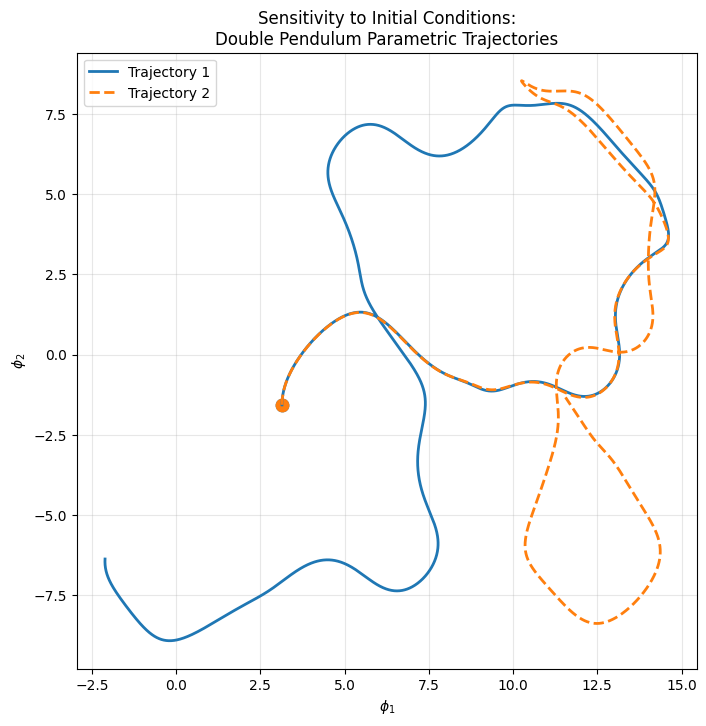

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# Physical parameters
# ============================================================

m1 = 1.0
m2 = 1.0

l1 = 1.0
l2 = 1.0

g = 9.81

# ============================================================
# Hamiltonian equations
# ============================================================

def rhs(t, y):

    phi1, phi2, p1, p2 = y

    delta = phi1 - phi2

    denom = (
        m1
        +
        m2 * np.sin(delta)**2
    )

    # --------------------------------------------------------
    # Angular velocities
    # --------------------------------------------------------

    phi1_dot = (

        p1 / l1**2
        -
        np.cos(delta) * p2 / (l1 * l2)

    ) / denom

    phi2_dot = (

        -(np.cos(delta) / (l1 * l2)) * p1
        +
        ((m1 + m2) / (m2 * l2**2)) * p2

    ) / denom

    # --------------------------------------------------------
    # Coupling term
    # --------------------------------------------------------

    coupling = (
        m2 * l1 * l2
        * phi1_dot
        * phi2_dot
        * np.sin(delta)
    )

    # --------------------------------------------------------
    # Momentum equations
    # --------------------------------------------------------

    p1_dot = (
        -coupling
        -
        (m1 + m2) * g * l1 * np.sin(phi1)
    )

    p2_dot = (
        coupling
        -
        m2 * g * l2 * np.sin(phi2)
    )

    return [
        phi1_dot,
        phi2_dot,
        p1_dot,
        p2_dot
    ]

# ============================================================
# Initial conditions
# ============================================================

# First trajectory

y0_1 = [
    np.pi/1,
    -np.pi/2,
    0.0,
    0.0
]

# Slightly perturbed trajectory

y0_2 = [
    np.pi/1 + 0.001,
    -np.pi/2 + 0.001,
    0.0,
    0.0
]

# ============================================================
# Time interval
# ============================================================

T = 10

t_eval = np.linspace(
    0,
    T,
    5000
)

# ============================================================
# Solve both systems
# ============================================================

sol1 = solve_ivp(

    rhs,

    [0, T],

    y0_1,

    t_eval=t_eval,

    rtol=1e-10,
    atol=1e-10

)

sol2 = solve_ivp(

    rhs,

    [0, T],

    y0_2,

    t_eval=t_eval,

    rtol=1e-10,
    atol=1e-10

)

# ============================================================
# Extract solutions
# ============================================================

phi1_1 = sol1.y[0]
phi2_1 = sol1.y[1]

phi1_2 = sol2.y[0]
phi2_2 = sol2.y[1]

# ============================================================
# Parametric plot
# ============================================================

plt.figure(figsize=(8,8))

plt.plot(

    phi1_1,
    phi2_1,

    linewidth=2,

    label='Trajectory 1'

)

plt.plot(

    phi1_2,
    phi2_2,

    '--',

    linewidth=2,

    label='Trajectory 2'

)

# Mark initial points

plt.scatter(
    phi1_1[0],
    phi2_1[0],
    s=80
)

plt.scatter(
    phi1_2[0],
    phi2_2[0],
    s=80
)

plt.xlabel(r'$\phi_1$')

plt.ylabel(r'$\phi_2$')

plt.title(
    'Sensitivity to Initial Conditions:\n'
    'Double Pendulum Parametric Trajectories'
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

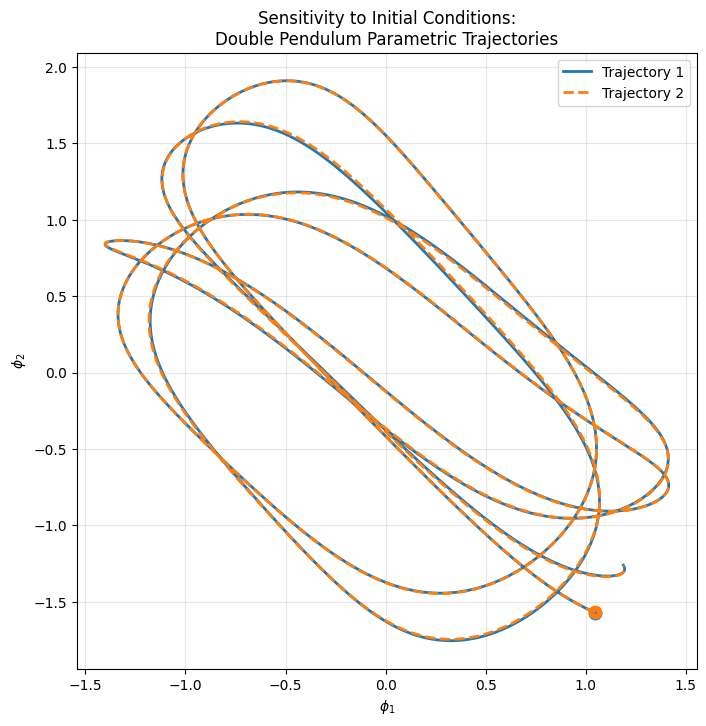

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# Physical parameters
# ============================================================

m1 = 1.0
m2 = 1.0

l1 = 1.0
l2 = 1.0

g = 9.81

# ============================================================
# Hamiltonian equations
# ============================================================

def rhs(t, y):

    phi1, phi2, p1, p2 = y

    delta = phi1 - phi2

    denom = (
        m1
        +
        m2 * np.sin(delta)**2
    )

    # --------------------------------------------------------
    # Angular velocities
    # --------------------------------------------------------

    phi1_dot = (

        p1 / l1**2
        -
        np.cos(delta) * p2 / (l1 * l2)

    ) / denom

    phi2_dot = (

        -(np.cos(delta) / (l1 * l2)) * p1
        +
        ((m1 + m2) / (m2 * l2**2)) * p2

    ) / denom

    # --------------------------------------------------------
    # Coupling term
    # --------------------------------------------------------

    coupling = (
        m2 * l1 * l2
        * phi1_dot
        * phi2_dot
        * np.sin(delta)
    )

    # --------------------------------------------------------
    # Momentum equations
    # --------------------------------------------------------

    p1_dot = (
        -coupling
        -
        (m1 + m2) * g * l1 * np.sin(phi1)
    )

    p2_dot = (
        coupling
        -
        m2 * g * l2 * np.sin(phi2)
    )

    return [
        phi1_dot,
        phi2_dot,
        p1_dot,
        p2_dot
    ]

# ============================================================
# Initial conditions
# ============================================================

# First trajectory

y0_1 = [
    np.pi/3,
    -np.pi/2,
    0.0,
    0.0
]

# Slightly perturbed trajectory

y0_2 = [
    np.pi/3 + 0.001,
    -np.pi/2 + 0.001,
    0.0,
    0.0
]

# ============================================================
# Time interval
# ============================================================

T = 10

t_eval = np.linspace(
    0,
    T,
    5000
)

# ============================================================
# Solve both systems
# ============================================================

sol1 = solve_ivp(

    rhs,

    [0, T],

    y0_1,

    t_eval=t_eval,

    rtol=1e-10,
    atol=1e-10

)

sol2 = solve_ivp(

    rhs,

    [0, T],

    y0_2,

    t_eval=t_eval,

    rtol=1e-10,
    atol=1e-10

)

# ============================================================
# Extract solutions
# ============================================================

phi1_1 = sol1.y[0]
phi2_1 = sol1.y[1]

phi1_2 = sol2.y[0]
phi2_2 = sol2.y[1]

# ============================================================
# Parametric plot
# ============================================================

plt.figure(figsize=(8,8))

plt.plot(

    phi1_1,
    phi2_1,

    linewidth=2,

    label='Trajectory 1'

)

plt.plot(

    phi1_2,
    phi2_2,

    '--',

    linewidth=2,

    label='Trajectory 2'

)

# Mark initial points

plt.scatter(
    phi1_1[0],
    phi2_1[0],
    s=80
)

plt.scatter(
    phi1_2[0],
    phi2_2[0],
    s=80
)

plt.xlabel(r'$\phi_1$')

plt.ylabel(r'$\phi_2$')

plt.title(
    'Sensitivity to Initial Conditions:\n'
    'Double Pendulum Parametric Trajectories'
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()